# Related Symbolic Music Corpora

This chapter introduces additional symbolic music datasets that can complement or extend analyses performed using:

    Turkish Makam Symbolic Phrase Dataset
    Turkish Makam Melodic Phrase Dataset


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import requests
from bs4 import BeautifulSoup

print("Environment ready.")

Environment ready.


In [2]:
PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()

WEBBOOK_ROOT = PROJECT_ROOT / "webbook"

RELATED_DATA = WEBBOOK_ROOT / "data" / "related"

RELATED_DATA.mkdir(parents=True, exist_ok=True)

print("Related data folder:")
print(RELATED_DATA)

Related data folder:
C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\related


In [3]:
DATASETS = {
    "symbolic_phrase": "http://compmusic.upf.edu/node/237",
    "melodic_phrase": "http://compmusic.upf.edu/node/236",
}

pd.DataFrame(
    {
        "Dataset": DATASETS.keys(),
        "URL": DATASETS.values(),
    }
)

,Dataset,URL
0,symbolic_phrase,http://compmusic.upf.edu/node/237
1,melodic_phrase,http://compmusic.upf.edu/node/236


In [4]:
pages = {}

for name, url in DATASETS.items():

    response = requests.get(url, timeout=30)

    print(
        f"{name}:",
        response.status_code
    )

    pages[name] = response.text

symbolic_phrase: 200
melodic_phrase: 200


In [5]:
for name, html in pages.items():

    output_file = RELATED_DATA / f"{name}.html"

    output_file.write_text(
        html,
        encoding="utf-8"
    )

print("Pages saved.")

Pages saved.


In [6]:
dataset_stats = []

for name, html in pages.items():

    soup = BeautifulSoup(
        html,
        "html.parser"
    )

    text = soup.get_text(
        separator=" ",
        strip=True
    )

    dataset_stats.append(
        {
            "dataset": name,
            "characters": len(text),
            "words": len(text.split())
        }
    )

stats_df = pd.DataFrame(dataset_stats)

stats_df

,dataset,characters,words
0,symbolic_phrase,2043,302
1,melodic_phrase,1686,253


In [7]:
stats_df.describe()

,characters,words
count,2.000000,2.000000
mean,1864.500000,277.500000
std,252.437121,34.648232
min,1686.000000,253.000000
25%,1775.250000,265.250000
50%,1864.500000,277.500000
75%,1953.750000,289.750000
max,2043.000000,302.000000


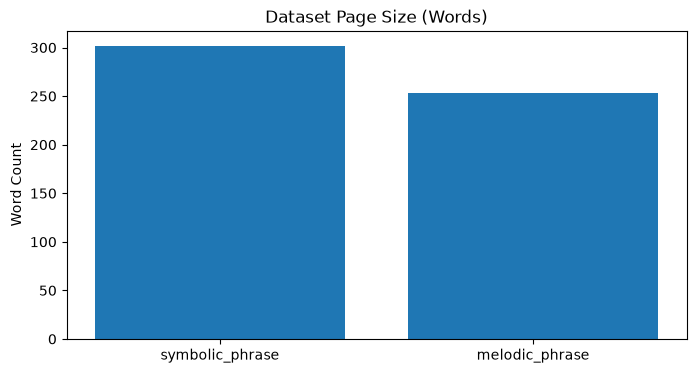

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    stats_df["dataset"],
    stats_df["words"]
)

plt.title(
    "Dataset Page Size (Words)"
)

plt.ylabel(
    "Word Count"
)

plt.show()

In [9]:
titles = []

for name, html in pages.items():

    soup = BeautifulSoup(
        html,
        "html.parser"
    )

    titles.append(
        {
            "dataset": name,
            "title": soup.title.text if soup.title else ""
        }
    )

pd.DataFrame(titles)

,dataset,title
0,symbolic_phrase,Turkish Makam Symbolic Phrase Dataset | Comput...
1,melodic_phrase,Turkish Makam Melodic Phrase Dataset | Computa...


In [10]:
summary = pd.DataFrame(
    {
        "Dataset": [
            "Turkish Makam Symbolic Phrase Dataset",
            "Turkish Makam Melodic Phrase Dataset"
        ],
        "URL": [
            "http://compmusic.upf.edu/node/237",
            "http://compmusic.upf.edu/node/236"
        ]
    }
)

summary

,Dataset,URL
0,Turkish Makam Symbolic Phrase Dataset,http://compmusic.upf.edu/node/237
1,Turkish Makam Melodic Phrase Dataset,http://compmusic.upf.edu/node/236


In [11]:
comparison = pd.DataFrame({
    "Dataset": [
        "Turkish Makam Symbolic Phrase Dataset",
        "Turkish Makam Melodic Phrase Dataset"
    ],
    "Project Page": [
        "http://compmusic.upf.edu/node/237",
        "http://compmusic.upf.edu/node/236"
    ],
    "Page Words": stats_df["words"].values,
    "Page Characters": stats_df["characters"].values
})

comparison

,Dataset,Project Page,Page Words,Page Characters
0,Turkish Makam Symbolic Phrase Dataset,http://compmusic.upf.edu/node/237,302,2043
1,Turkish Makam Melodic Phrase Dataset,http://compmusic.upf.edu/node/236,253,1686
